# Regression — California Housing

Predict the median house value (`MedHouseVal`) of California districts from 8 numeric features
(1990 US Census). Algorithm: **linear regression trained with gradient descent** (`SGDRegressor`),
validated on an 80/20 holdout and compared against WEKA.

This uses a **different method** from the classification notebook (which uses KNN and Decision
Tree), as required by the assignment (point 5).

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

data = pd.read_csv('../datasets/california_housing.csv')

## Dataset

| Feature | Description |
|---|---|
| MedInc | Median income in the district |
| HouseAge | Median house age |
| AveRooms | Average rooms per household |
| AveBedrms | Average bedrooms per household |
| Population | District population |
| AveOccup | Average household occupancy |
| Latitude / Longitude | District location |
| **MedHouseVal** | **Target** — median house value (×100,000 USD) |

In [96]:
display(data.head())
data.info()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Missing values and statistics
Check for missing data and inspect the range of each feature (useful to anticipate scaling).

In [97]:
print("Missing values:\n", data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicate rows: 0


## Feature relationships
Correlation matrix between features and target. Strongly correlated feature pairs (e.g.
`AveRooms` and `AveBedrms`) carry redundant information — relevant for a linear model, where
multicollinearity inflates coefficient variance.

The target is right-censored at 5.0 ($500k): values above are clipped, hence the spike at 5 and the vertical stripe in predicted-vs-actual. We keep these rows (standard use of this dataset); a fully correct treatment would need a censored-regression model (e.g. Tobit), out of scope here.

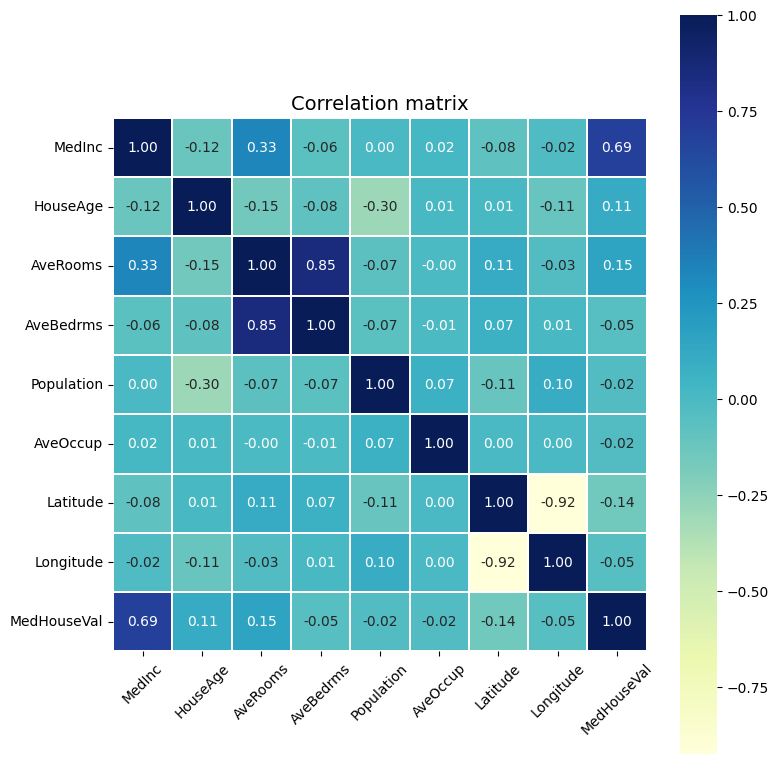

In [98]:
# data = data[data['MedHouseVal'] < 5.0].reset_index(drop=True)

plt.figure(figsize=(8, 8))
sns.heatmap(data.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='YlGnBu', 
            square=True, 
            linewidths=0.1)
plt.title('Correlation matrix', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

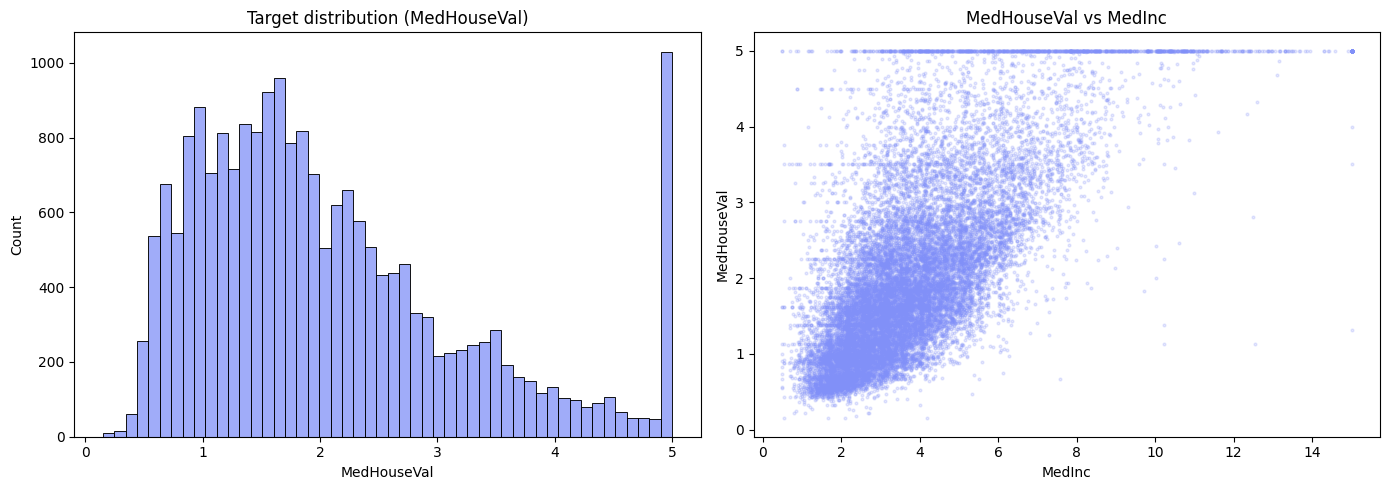

In [99]:


fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data['MedHouseVal'], bins=50, color='#8190f8', ax=ax[0])
ax[0].set_title('Target distribution (MedHouseVal)')
ax[1].scatter(data['MedInc'], data['MedHouseVal'], s=4, alpha=0.2, color='#8190f8')
ax[1].set_xlabel('MedInc'); ax[1].set_ylabel('MedHouseVal')
ax[1].set_title('MedHouseVal vs MedInc')
plt.tight_layout()
plt.show()

# Splitting the dataset

In [100]:
X = data.drop(columns=['MedHouseVal'])
y = data['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print('X_train', X_train.shape, '| X_test', X_test.shape)

X_train (16512, 8) | X_test (4128, 8)


## Feature selection (mutual information)
**Mutual information** measures how much each feature reduces the uncertainty on the target,
capturing non-linear dependencies too (≥ 0; 0 = independent). It is computed on the **training
set only** to avoid leakage. We keep the features with MI > 0.05.

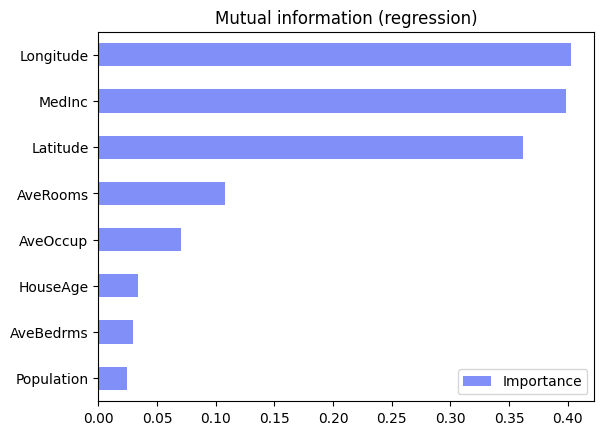

,Importance
Longitude,0.402514
MedInc,0.398703
Latitude,0.361702
AveRooms,0.107764
AveOccup,0.070166
HouseAge,0.033379
AveBedrms,0.029812
Population,0.024354


In [101]:
mi = mutual_info_regression(X_train, y_train, random_state=0)
ft_import = pd.DataFrame({'Importance': mi}, index=X_train.columns).sort_values('Importance', ascending=False)

ft_import.plot(kind='barh', color='#8190f8')
plt.title('Mutual information (regression)')
plt.gca().invert_yaxis()
plt.show()
ft_import

In [102]:
selected = ft_import[ft_import['Importance'] > 0.05].index.tolist()
X_train = X_train[selected]
X_test  = X_test[selected]
print('Selected features:', selected)

Selected features: ['Longitude', 'MedInc', 'Latitude', 'AveRooms', 'AveOccup']


## Model training and validation
We train **three** regression algorithms from the list: **linear regression via SGD** (`SGDRegressor`),
**KNN regression** and **Decision Tree regression**. Each runs in a pipeline that scales the features
to [0, 1] with `MinMaxScaler` (SGD diverges with plain standardization because of California's extreme
outliers; bounding to [0, 1] keeps the gradient stable — also what WEKA's SGD does internally).

Metrics on the 20% holdout:
- **R²** — fraction of target variance explained;
- **MAE** — mean absolute error (same unit as the target);
- **RMSE** — root mean squared error (penalizes large errors more).

In [103]:
models = {
    'LinearRegression_SGD': SGDRegressor(loss='squared_error', max_iter=1000, random_state=42),
    'KNN':                  KNeighborsRegressor(),
    'DecisionTree':         DecisionTreeRegressor(random_state=42),
}

rows, preds = [], {}
for name, model in models.items():
    pipe = Pipeline([('scaler', MinMaxScaler()), ('regressor', model)])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    preds[name] = yp
    rows.append({'R2':   r2_score(y_test, yp),
                 'MAE':  mean_absolute_error(y_test, yp),
                 'RMSE': np.sqrt(mean_squared_error(y_test, yp))})

reg_scores = pd.DataFrame(rows, index=list(models))
reg_scores

,R2,MAE,RMSE
LinearRegression_SGD,0.526051,0.579663,0.786135
KNN,0.786476,0.348769,0.527660
DecisionTree,0.602284,0.458809,0.720141


## Evaluation
Predicted vs. actual values (the closer to the diagonal, the better) and the residual
distribution (should be centred on zero with no visible structure).

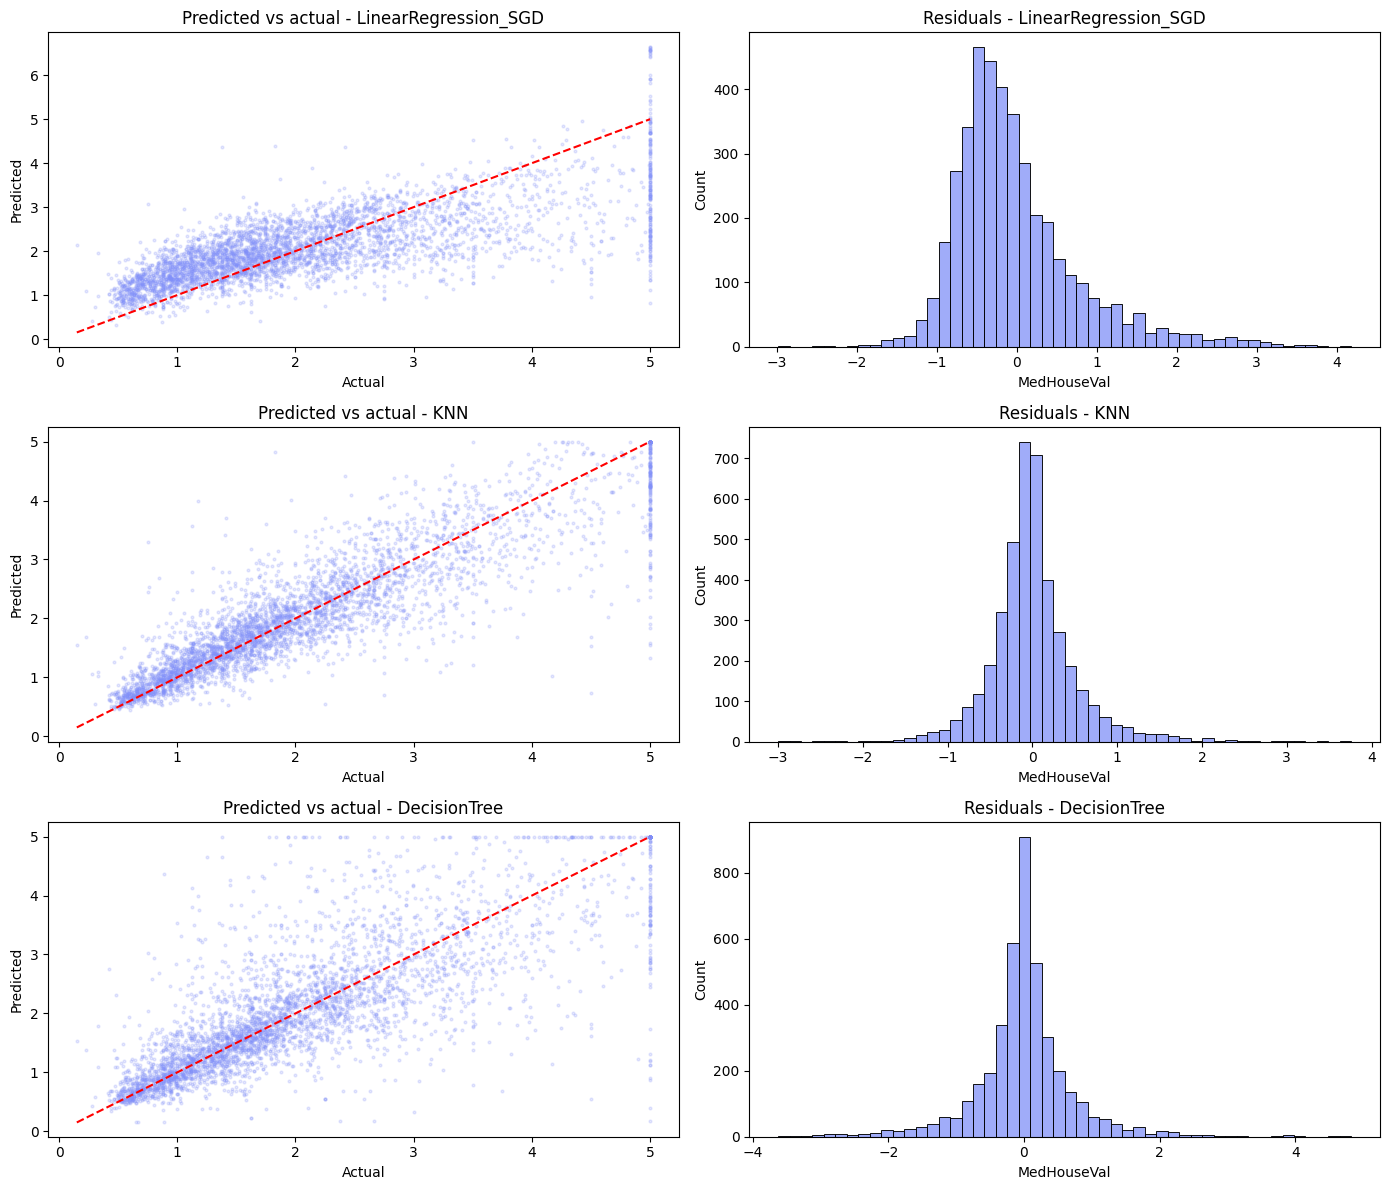

In [104]:
fig, axes = plt.subplots(len(preds), 2, figsize=(14, 4*len(preds)))
for row, (name, yp) in enumerate(preds.items()):
    ax = axes[row]
    ax[0].scatter(y_test, yp, s=4, alpha=0.2, color='#8190f8')
    lims = [y_test.min(), y_test.max()]
    ax[0].plot(lims, lims, 'r--')
    ax[0].set_xlabel('Actual'); ax[0].set_ylabel('Predicted')
    ax[0].set_title(f'Predicted vs actual - {name}')
    sns.histplot(y_test - yp, bins=50, color='#8190f8', ax=ax[1])
    ax[1].set_title(f'Residuals - {name}')
plt.tight_layout()
plt.show()


In [105]:
# Generating .arff file for WEKA
dataset_weka = pd.concat([X[selected], y], axis=1)
nome_file = "../weka-files/california_housing.arff"

with open(nome_file, "w") as f:
    f.write("@RELATION california_housing\n\n")
    for col in dataset_weka.columns:
        f.write(f'@ATTRIBUTE "{col}" NUMERIC\n')
    f.write("\n@DATA\n")
    dataset_weka.fillna('?').to_csv(f, header=False, index=False)
print(f"File '{nome_file}' generated. {len(dataset_weka.columns)} numeric attributes "
      f"(target = 'MedHouseVal').")

File '../weka-files/california_housing.arff' generated. 6 numeric attributes (target = 'MedHouseVal').


## scikit-learn vs WEKA comparison

Same protocol: 80/20 holdout + standardized features, linear regression.

Run WEKA with `weka-files/run_weka_regression.sh`, then paste the metrics into `weka_results`
below. WEKA's `functions.LinearRegression` reports MAE and RMSE directly; for R² use the square
of WEKA's *Correlation coefficient*. Full recipe in the [README](../README.md).

In [106]:
# scikit-learn results
sklearn_scores = reg_scores.copy()
sklearn_scores.columns = ['R2_sklearn', 'MAE_sklearn', 'RMSE_sklearn']

# WEKA results
# To insert different results run weka-files/run_weka_regression.sh and paste values here
weka_results = {  # from run_weka_regression.sh, full data (cap kept) ([R2=corr^2, MAE, RMSE])
    'LinearRegression_SGD': [0.586, 0.559, 0.745],
    'KNN':                  [0.863, 0.279, 0.428],
    'DecisionTree':         [0.822, 0.322, 0.487],
}
weka_scores = pd.DataFrame.from_dict(weka_results, orient='index',
                                     columns=['R2_weka', 'MAE_weka', 'RMSE_weka']).astype(float)

comparison = sklearn_scores.join(weka_scores)
comparison = comparison[['R2_sklearn', 'R2_weka', 'MAE_sklearn', 'MAE_weka', 'RMSE_sklearn', 'RMSE_weka']]
comparison.round(3)

,R2_sklearn,R2_weka,MAE_sklearn,MAE_weka,RMSE_sklearn,RMSE_weka
LinearRegression_SGD,0.526,0.586,0.580,0.559,0.786,0.745
KNN,0.786,0.863,0.349,0.279,0.528,0.428
DecisionTree,0.602,0.822,0.459,0.322,0.720,0.487


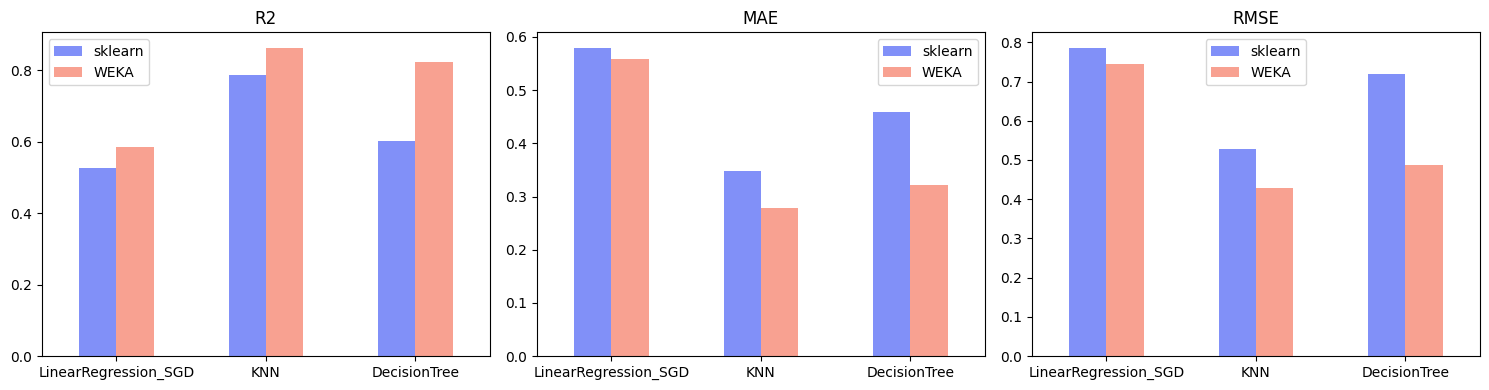

In [107]:
metrics = ['R2', 'MAE', 'RMSE']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, metrics):
    comparison[[f'{m}_sklearn', f'{m}_weka']].plot(kind='bar', ax=ax, color=['#8190f8', '#f8a191'], legend=True)
    ax.set_title(m); ax.legend(['sklearn', 'WEKA'])
    ax.set_xticklabels(comparison.index, rotation=0)
plt.tight_layout()
plt.show()